<a href="https://colab.research.google.com/github/nomanabdullah04/MaChineLearning/blob/MachineLearning/LogisticRegressionAlgo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Logistic regression Algorithm

---



Logistic regression is a supervised machine learning and statistical algorithm **used to predict the probability of a categorical dependent variable.** Unlike linear regression which predicts continuous values (like house prices), logistic regression is predominantly used for classification tasks where the outcome is discrete (such as predicting whether an email is "Spam" or "Not Spam")



# Why Linear Regression Fails for Classification

Based on visual analysis of data distributions (such as Study Hours vs. Pass/Fail outcomes), Linear Regression fails as a classifier due to two fundamental mathematical issues.

---

### 1. Outlier Distortion (The "Shifted Boundary" Problem)
* **The Mechanism:** Linear Regression uses **Ordinary Least Squares (OLS)** optimization, which minimizes the sum of squared residuals:
$$\text{Cost} = \sum (y_{\text{actual}} - y_{\text{predicted}})^2$$
* **The Failure:** When a data point exists far to the right (e.g., a student studying 8+ hours who easily passes), it creates a massive squared error relative to the original regression line.
* **The Impact:** To minimize this penalty, the entire straight line is forced to tilt and flatten out. This shift pulls the $0.5$ decision threshold to the right, causing borderline positive cases (e.g., a student studying 5 hours) to be incorrectly reclassified as a **0 (Fail)** instead of a **1 (Pass)**.

---

### 2. Nonsensical Predictions ($>1$ and $<0$)
* **The Mechanism:** The mathematical equation for a straight regression line is entirely unconstrained:
$$y = \beta_0 + \beta_1x$$
* **The Failure:** As $x$ (Study Hours) approaches $0$ or goes negative, the predicted output $y$ drops below $0$. Conversely, as $x$ grows large, $y$ scales infinitely past $1$.
* **The Impact:** In classification, outputs represent probabilities ($P(\text{Class}=1)$), which must strictly reside within a closed interval:
$$0 \le P(y) \le 1$$
Linear Regression yields mathematically invalid probabilities like $-0.3$ or $1.4$, making direct thresholding highly unstable.

---

### The Solution: Logistic Regression
Logistic Regression resolves both flaws simultaneously by wrapping the linear equation inside the **Sigmoid function**:
$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

1. **Strict Bounds:** The S-shaped curve mathematically forces all outputs to stay strictly between $0$ and $1$, regardless of how extreme the inputs are.
2. **Outlier Immunity:** Instead of OLS, it uses **Maximum Likelihood Estimation (MLE)**. Once a point is securely predicted as a $1$, pushing it further out (e.g., from 6 hours to 12 hours) does not alter or tilt the curve, leaving the decision boundary completely undisturbed.


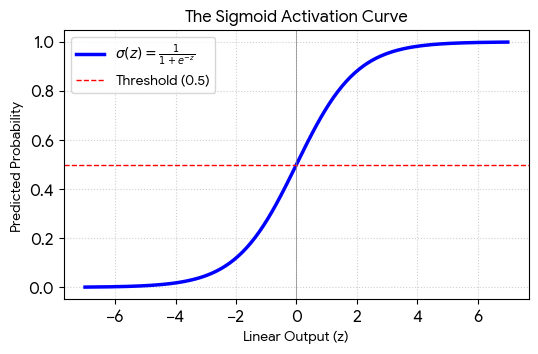

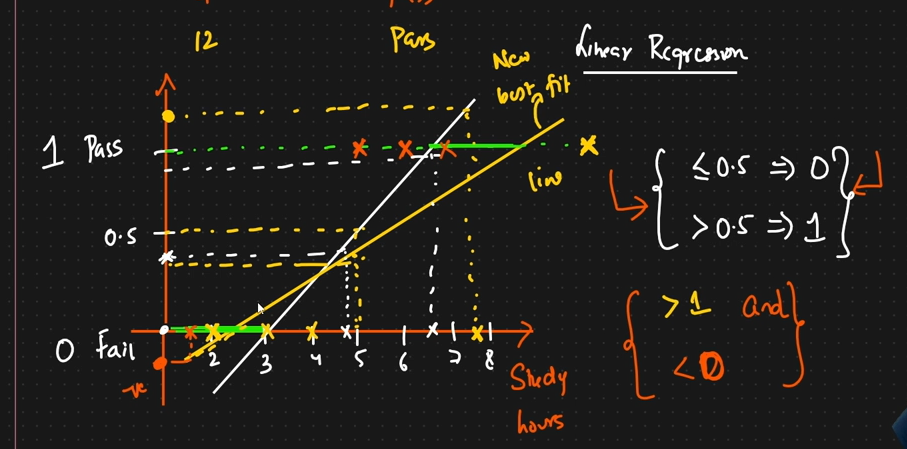

# How Logistic Regression Solves Classification Problems

In classification tasks (like predicting whether a student will **Pass (1)** or **Fail (0)** based on study hours), our goal is to predict discrete categorical outputs. While Linear Regression is excellent for continuous data, it fails when applied directly to classification problems. Here is how Logistic Regression fixes those failures.

---

## 1. Why Linear Regression Fails for Classification
If we try to use a standard linear regression model $h_\theta(x) = \theta_0 + \theta_1 x_1$ to fit binary classification data, we run into two major limitations:

### Issue A: Sensitivity to Outliers (Shifted Decision Boundary)
* **Standard Data:** Initially, a linear regression line might place a threshold at $0.5$ reasonably well (e.g., studying $> 3$ hours passes).
* **The Outlier Effect:** If an extreme outlier appears—such as a student who studied $8$ hours and passed—the linear model minimizes the overall squared error by flattening its slope to accommodate this point (creating a "New best fit line").
* **The Failure:** This flattening shifts the $0.5$ decision threshold significantly to the right. Consequently, borderline data points that were previously classified correctly (e.g., $4$ hours) are now incorrectly flipped to the wrong class.

### Issue B: Nonsensical Predictions
* **Infinite Extrapolation:** A straight line continues infinitely in both directions. For very low study hours, it outputs negative numbers ($< 0$). For very high study hours, it outputs values greater than $1$ ($> 1$).
* **The Failure:** In classification, outputs represent probabilities, which must mathematically reside strictly within a closed interval: $[0, 1]$. Linear regression yields invalid probability scores.

---

## 2. The Solution: Sigmoid Activation Function
To overcome these issues, Logistic Regression passes the linear combination $z = \theta_0 + \theta_1 x_1$ through the **Sigmoid (Logistic) Function**:

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

### Properties of the Sigmoid Function:
* It squashes any real-valued number $z$ into a strict, bounded probability range between $0$ and $1$.
* If $z \geq 0$, then $\sigma(z) \geq 0.5$ (Predicts Class $1$).
* If $z < 0$, then $\sigma(z) < 0.5$ (Predicts Class $0$).

### The Logistic Hypothesis Formula:
$$h_\theta(x) = \sigma(\theta_0 + \theta_1 x_1) = \frac{1}{1 + e^{-(\theta_0 + \theta_1 x_1)}}$$

This output is explicitly interpreted as the **probability** that the given input belongs to the positive class ($y = 1$).

---

## 3. The Need for a New Cost Function
In Linear Regression, we optimize our parameters using the **Mean Squared Error (MSE)** cost function:

$$J(\theta_0, \theta_1) = \frac{1}{2m} \sum_{i=1}^{m} \left(h_\theta(x)^{(i)} - y^{(i)}\right)^2$$

If we plug the non-linear Sigmoid hypothesis $h_\theta(x) = \frac{1}{1+e^{-z}}$ into MSE, the resulting mathematical surface landscape becomes **Non-Convex**:
* **Convex Function:** Features a single **Global Minimum**. Optimization algorithms like Gradient Descent are mathematically guaranteed to find it.
* **Non-Convex Function:** Populated by multiple wavy **Local Minima**. Gradient descent can get trapped in a suboptimal ditch, failing to find the true globally optimal parameters.


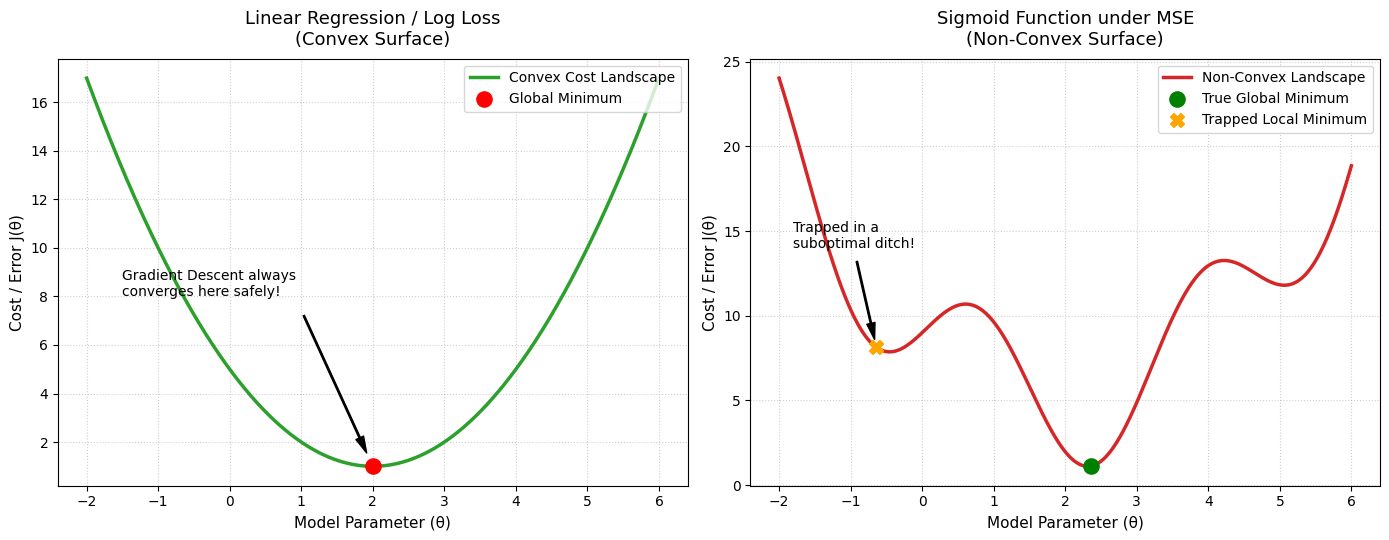
---

## 4. Logistic Regression Cost Function (Log Loss)
To keep our optimization landscape strictly **Convex**, we use the **Log Loss (Cross-Entropy)** cost function. For a single training example, the penalty is split conditionally based on the true label:

$$\text{Cost}\left(h_\theta(x)^{(i)}, y^{(i)}\right) =
\begin{cases}
-\log\left(h_\theta(x)^{(i)}\right) & \text{if } y^{(i)} = 1 \\
-\log\left(1 - h_\theta(x)^{(i)}\right) & \text{if } y^{(i)} = 0
\end{cases}$$

### Why does this work intuitively?
* **If $y = 1$:** If the model correctly predicts a high probability ($h_\theta(x) \to 1$), the cost is $-\log(1) = 0$ (Zero penalty). If the model confidently misclassifies it ($h_\theta(x) \to 0$), the cost approaches infinity ($-\log(0) \to \infty$).
* **If $y = 0$:** If the model correctly predicts a low probability ($h_\theta(x) \to 0$), the cost is $-\log(1) = 0$. If it confidently misclassifies it ($h_\theta(x) \to 1$), the cost approaches infinity ($-\log(0) \to \infty$).

### The Simplified (Combined) Form
To optimize and differentiate this efficiently, we compress the two conditional statements into a single line:

$$\text{Cost}\left(h_\theta(x)^{(i)}, y^{(i)}\right) = -y^{(i)} \log\left(h_\theta(x)^{(i)}\right) - \left(1 - y^{(i)}\right) \log\left(1 - h_\theta(x)^{(i)}\right)$$

### The Final Logistic Regression Cost Function $J(\theta)$
Summing and averaging over all $m$ training examples yields our final, completely convex optimization objective:

$$J(\theta) = -\frac{1}{m} \sum_{i=1}^{m} \left[ y^{(i)} \log\left(h_\theta(x)^{(i)}\right) + \left(1 - y^{(i)}\right) \log\left(1 - h_\theta(x)^{(i)}\right) \right]$$

*(Note: The scalar denominator factor of $2$ typically found in linear regression is dropped here because it is a mathematical convention tied exclusively to canceling exponents during the differentiation of squared errors, which does not apply to logarithmic loss calculus).*


# **Performence Metric**

---

# Classification Performance Metrics

After training a Logistic Regression model, we must evaluate its performance. Relying solely on raw predictions can be misleading, especially with imbalanced datasets. Here is the mathematical and structural breakdown of the five core evaluation metrics.

---

## 1. Confusion Matrix
A **Confusion Matrix** is a structural layout that visualizes the performance of a classification algorithm. It cross-references the actual target labels against the values predicted by the model.

### The Layout Diagram

```text
                      ACTUAL CLASS
                  Positive (1)     Negative (0)
               +----------------+----------------+
  Positive (1) | True Positive  | False Positive |
P              |      (TP)      |      (FP)      |
R PREDICTED    +----------------+----------------+
E CLASS        | False Negative | True Negative  |
D Negative (0) |      (FN)      |      (TN)      |
               +----------------+----------------+
```

### Key Terms:
* **True Positive (TP):** Model predicted Positive (\(1\)), and it is True. (e.g., Patient has a disease, model detected it).
* **True Negative (TN):** Model predicted Negative (\(0\)), and it is True. (e.g., Patient is healthy, model declared them healthy).
* **False Positive (FP) [Type I Error]:** Model predicted Positive (\(1\)), but it is False. (e.g., Patient is healthy, but model flags them as sick).
* **False Negative (FN) [Type II Error]:** Model predicted Negative (\(0\)), but it is False. (e.g., Patient has a disease, but model misses it entirely).

---

## 2. Accuracy
**Accuracy** measures the proportion of total predictions (both positive and negative) that the model got correct.

### Mathematical Law
$$\text{Accuracy} = \frac{\text{True Predictions}}{\text{Total Predictions}} = \frac{\text{TP} + \text{TN}}{\text{TP} + \text{TN} + \text{FP} + \text{FN}}$$

### Critical Flaw Diagram
Imagine an imbalanced dataset containing \(100\) patients where \(95\) are Healthy and \(5\) are Sick:

```text
Actual Dataset:   [ 95 Healthy (0) ]  [ 5 Sick (1) ]
Dumb Model Predicts: ALL HEALTHY (0)
Resulting Matrix: TN = 95, FN = 5, TP = 0, FP = 0

Accuracy Calculus: 95 / 100 = 95% Accuracy!
```
* **Conclusion:** Even though the accuracy is a high \(95\%\), the model is entirely useless because it caught \(0\%\) of the sick individuals.

---

## 3. Precision
**Precision** answers the question: *"Out of all the examples the model predicted as Positive, how many were actually Positive?"* It focuses heavily on minimizing **False Positives**.

### 📐 Mathematical Law
$$\text{Precision} = \frac{\text{True Positives}}{\text{Total Predicted Positives}} = \frac{\text{TP}}{\text{TP} + \text{FP}}$$


### Visual Target Diagram
```text
  [ All Positive Predictions (TP + FP) ]
  +------------------------------------+

  |  False Positives (FP)  |   TP  |  <-- Precision maximizes the size
  +------------------------------------+      of TP inside this bubble.
```
* **Use Case:** High precision is critical when the cost of a False Positive is high. For example, in **Spam Filtering**, a False Positive means a crucial work email is incorrectly dumped into the spam folder.

---

## 4. Recall (Sensitivity)
**Recall** answers the question: *"Out of all the actual Positive cases that exist, how many did the model successfully find?"* It focuses heavily on minimizing **False Negatives**.

###  Mathematical Law
$$\text{Recall} = \frac{\text{True Positives}}{\text{Total Actual Positives}} = \frac{\text{TP}}{\text{TP} + \text{FN}}$$


###  Visual Target Diagram
```text
  [ All Actual Positive Cases (TP + FN) ]
  +------------------------------------+

  |  False Negatives (FN)  |   TP   |  <-- Recall maximizes how much of
  +------------------------------------+      the real target is captured.
```
* **Use Case:** High recall is mandatory when the cost of a False Negative is catastrophic. For example, in **Cancer Detection**, missing a sick patient (False Negative) means they leave untreated, which is life-threatening.

---

## 5. F-Beta Score
The **$F_\beta$ Score** provides a tunable harmonic mean between Precision and Recall. It uses a coefficient factor ($\beta$) to allow machine learning engineers to balance the importance of one metric over the other.

###  Mathematical Law
$$F_\beta = (1 + \beta^2) \cdot \frac{\text{Precision} \cdot \text{Recall}}{(\beta^2 \cdot \text{Precision}) + \text{Recall}}$$

### Tuning Behaviors ($\beta$ Weighting):

* **$\beta = 1$ ($F_1$ Score):** Gives **equal weight** to Precision and Recall. It is the harmonic mean of both:
  $$F_1 = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$$

* **$\beta = 0.5$ ($F_{0.5}$ Score):** Attaches **more importance to Precision** than Recall. It dampens the penalty of False Negatives and punishes False Positives harder.

* **$\beta = 2$ ($F_2$ Score):** Attaches **more importance to Recall** than Precision. It heavily punishes missed cases (False Negatives).



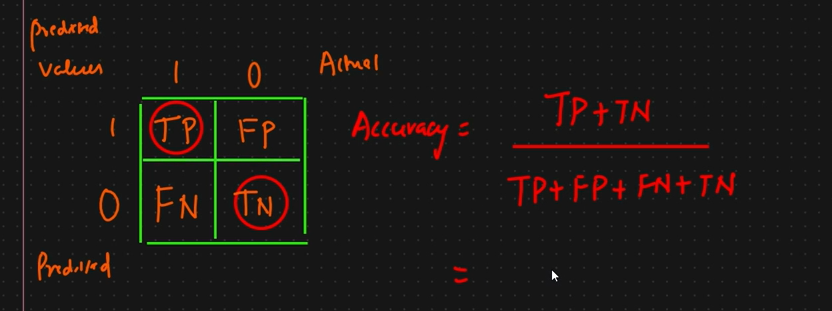


# Logistic Regression OVR

---

# Multiclass Classification: One-vs-Rest (OVR) Strategy

By default, standard Logistic Regression is a binary classifier (handles only two classes, like \(0\) and \(1\)). To handle **Multiclass Classification** (predicting three or more distinct classes, such as Cat vs. Dog vs. Bird), we must use an architectural wrapper strategy. The most common approach is **One-vs-Rest (OVR)**, also known as **One-vs-All (OVA)**.

---

## 1. How the OVR Strategy Works
Instead of trying to separate all classes simultaneously with a single complex boundary, OVR breaks down a multiclass problem with \(K\) distinct classes into **\(K\) separate, independent binary classification models**.

For each individual model, one specific class is assigned as the **Positive Class (\(1\))**, while all other remaining classes are clumped together to form the **Negative Class (\(0\))**.

```text
Multiclass Dataset (Classes: Red, Blue, Green)
     │
     ├──► Classifier 1:  [Red] (1)   vs.  [Blue + Green] (0)
     ├──► Classifier 2:  [Blue] (1)  vs.  [Red + Green] (0)
     └──► Classifier 3:  [Green] (1) vs.  [Red + Blue] (0)
```

---

## 2. Mathematical Decision Rule
During the inference/prediction phase, an unseen data sample \(x\) is fed into all \(K\) binary models concurrently. Each classifier outputs an independent probability score indicating how confident it is that the sample belongs to its positive class.

The final system prediction is simply the class whose corresponding model yields the **highest probability value**:

$$\text{Prediction} = \arg\max_{k} \left( h_\theta^{(k)}(x) \right)$$

Where $h_\theta^{(k)}(x)$ represents the sigmoid probability output generated by the $k$-th classifier.

---

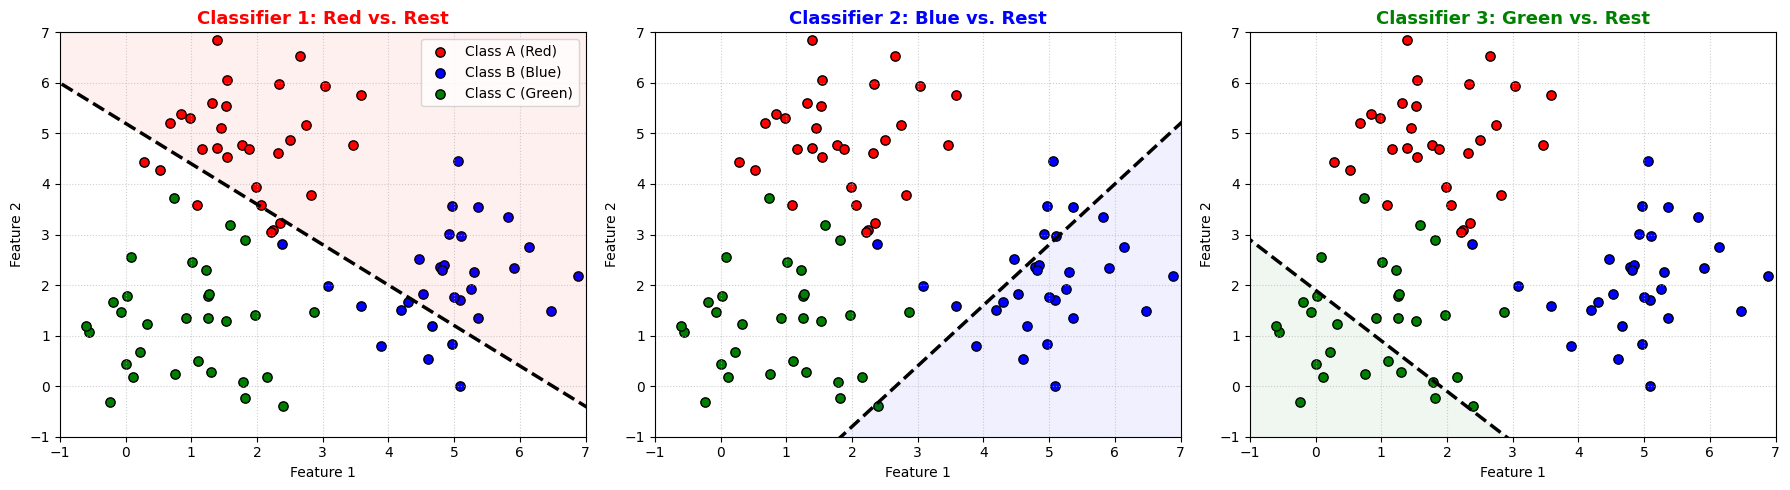


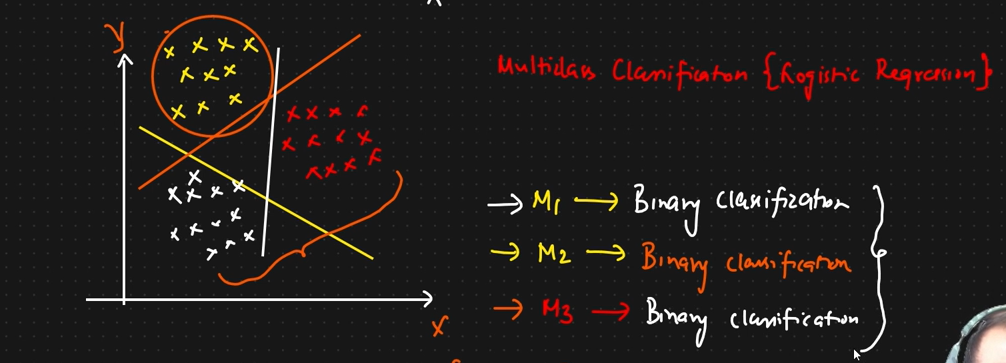

# **Logistic Regression Implementation**

In [3]:
#Import basic libris
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [4]:
from sklearn.datasets import make_classification